# 2.10 Hamilton–Jacobi Theory and Action-Angle Variables

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume II — Analytical Mechanics",
    number="2.10",
    title="Hamilton–Jacobi Theory and Action-Angle Variables",
    blurb="Mechanics at the edge of wave physics. The boldest formulation of "
    "classical mechanics looks for a change of variables so perfect that the "
    "motion becomes standing still — every new coordinate a constant — and the "
    "function that accomplishes it obeys a single equation for the classical "
    "action. That action turns out to be a phase, the invariant tori it defines "
    "are the ones chaos respects, and the equation it obeys is what the "
    "Schrödinger equation becomes when the wavelength shrinks to nothing.",
    difficulty="advanced",
    estimate="160–195 min",
)

<ECP header: 2837 chars of HTML>

## Notebook overview

[§2.1](lagrangian-sympy.ipynb) built mechanics from a single scalar, the Lagrangian $\mathcal
L(q,\dot q,t)$; [§2.3](hamiltonian-phase-flow.ipynb) traded velocity for momentum and recast the
dynamics as an incompressible *flow* on phase space, governed by Hamilton's
equations and the Poisson bracket. This notebook completes that arc with its
third and most powerful formulation. The idea is audacious: instead of solving
the equations of motion, find a **canonical transformation** (the bracket-
preserving maps of [§2.3](hamiltonian-phase-flow.ipynb)) so clever that in the new coordinates *nothing moves* —
every new coordinate and momentum is a constant of the motion. The generating
function that accomplishes this is **Hamilton's principal function** $S$, and
the single first-order partial differential equation it must satisfy is the
**Hamilton–Jacobi equation**. Solving that one equation solves the mechanics.

The reward is not merely another route to the same trajectories. $S$ turns out
to be the **action** $\int p\,\mathrm dq$ we have met since [§2.1](lagrangian-sympy.ipynb), now
promoted to the generator of the motion; its gradient is the momentum, and its
level sets are wavefronts that the trajectories cross at right angles. For
bounded motion the natural coordinates become **action-angle variables**: an
action $J=\frac1{2\pi}\oint p\,\mathrm dq$ that is constant, and an angle that
winds at a steady frequency. The action variables label the invariant **tori**
a trajectory wraps (the tori of [§5.5](../05-classical-stat-mech/ergodicity.ipynb)), and they are **adiabatic
invariants** — nearly conserved when the system is deformed slowly. Above all,
$S$ has the units and the role of a **phase**: if a particle is secretly a wave
with phase $S/\hbar$, then the Hamilton–Jacobi equation is exactly what the
Schrödinger equation collapses into as the wavelength vanishes. That is the door
through which Volume VI enters, and the Outlook of [§2.3](hamiltonian-phase-flow.ipynb) already pointed at it.

You build the compact toolkit yourself — the momentum, Hamilton's
characteristic function by quadrature, the action variable as an enclosed
phase-space area, the frequency read off as $\partial H/\partial J$ — while
Setup supplies only a turning-point finder. Then we put it to work on the free
particle and the harmonic oscillator: recovering uniform motion and the
oscillation from the Hamilton–Jacobi equation, computing the action and its
frequency, watching the action survive a slow change that the energy does not,
and finally quantizing
the action the way the old quantum theory did, one step short of the correction
that Volume VI's WKB approximation ([§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb)) supplies.

> **How to read the checks.** Each exercise ends with a validation that compares
> a computed result to an expected physical fact. A ✗ does *not* by itself mean
> the physics is wrong: it means the output didn't match what the check
> expected, which may be a real error, a different-but-valid convention (a sign,
> a unit, an array order), or simply too tight a tolerance. Treat a ✗ as a
> prompt to locate the discrepancy; passing is strong evidence of correctness,
> not proof.

> **Scope.** This is a working review, not a textbook chapter. For Hamilton–
> Jacobi theory and action-angle variables in full — the separation of
> variables, the connection to canonical perturbation theory, and integrability
> — see Goldstein, Poole & Safko {cite}`goldstein` (ch. 10), Landau & Lifshitz,
> *Mechanics* {cite}`landau_mechanics` (§45–52), and Nolting, *Theoretical
> Physics 2* {cite}`nolting2`.

## Theory in brief

### The Hamilton–Jacobi idea

Seek a canonical transformation $(q,p)\mapsto(Q,P)$ — one of the bracket-
preserving maps of [§2.3](hamiltonian-phase-flow.ipynb) — whose *new* Hamiltonian $K$ is identically
**zero**. Then Hamilton's equations in the new variables read $\dot Q=\partial
K/\partial P=0$ and $\dot P=-\partial K/\partial Q=0$: every new coordinate and
momentum is a constant. A type-2 generating function $S(q,P,t)$ produces such a
transformation with $p=\partial S/\partial q$ and $K=H+\partial S/\partial t$,
so demanding $K=0$ gives the **Hamilton–Jacobi equation**

```{math}
:label: eq-hj-idea
H\!\left(q,\ \frac{\partial S}{\partial q},\ t\right) + \frac{\partial
S}{\partial t} = 0 ,
```

one first-order PDE for **Hamilton's principal function** $S(q,t)$. Solving it
solves the dynamics: the constant new coordinates and momenta are the
integration constants, and inverting the relations $\,\partial S/\partial
P=Q=\text{const}$ returns $q(t)$.

### Separation for conserved systems

When $H$ has no explicit time dependence, $S$ separates into a time piece and a
space piece,

```{math}
:label: eq-hj-separation
S(q,t) = W(q) - E\,t , \qquad H\!\left(q, \frac{\partial W}{\partial q}\right) =
E ,
```

where $E$ is the conserved energy and $W(q)$ is **Hamilton's characteristic
function**. Because $\partial W/\partial q = p$, the characteristic function is
the **action** accumulated along the path,

```{math}
:label: eq-char-action
W(q) = \int p\,\mathrm dq = \int \sqrt{2m\,[E-V(q)]}\;\mathrm dq ,
```

the same $\int p\,\mathrm dq$ that runs through all of mechanics, now serving as
the generator of the motion. The momentum is literally the slope of the action.

### Separation of variables and integrability

For special systems the characteristic function splits into a sum of one-
coordinate pieces, $W=\sum_i W_i(q_i)$, turning the PDE {eq}`eq-hj-idea` into
ordinary integrals — the classical route to central-force and other symmetric
problems ([§2.4](central-force.ipynb)). A system with as many independent conserved actions as
degrees of freedom is **integrable**, and its bounded motion lies on nested
**tori**; most systems have no such separation, and their trajectories fill the
energy surface ergodically ([§5.5](../05-classical-stat-mech/ergodicity.ipynb)). Hamilton–Jacobi theory is thus also
the sharp dividing line between the solvable and the chaotic.

### Action-angle variables

For bounded, periodic motion the most natural variables are **action-angle**
variables. The **action** is the phase-space area enclosed by one orbit, divided
by $2\pi$,

```{math}
:label: eq-action-angle
J = \frac{1}{2\pi}\oint p\,\mathrm dq , \qquad \dot\theta =
\frac{\partial H}{\partial J} \equiv \omega ,
```

a constant of the motion, and its conjugate **angle** $\theta$ advances linearly
in time at the frequency $\omega=\partial H/\partial J$. In these coordinates the
dynamics is trivial: $J$ fixed, $\theta$ winding at a steady rate. For the
harmonic oscillator $J=E/\omega$ and $H(J)=\omega J$, so $\partial H/\partial
J=\omega$ recovers the frequency. The action variables label the invariant tori
([§5.5](../05-classical-stat-mech/ergodicity.ipynb)) and are **adiabatic invariants**: when a parameter is changed slowly, $J$
is nearly conserved even though $E$ is not — the pendulum whose length is slowly
drawn up keeps its action, not its energy.

### The action as a phase — the seam to quantum mechanics

Hamilton–Jacobi theory casts mechanics around the action $S$, and $S/\hbar$ is
dimensionless: $S$ has the units and the role of a **phase**. This is no
accident. If a particle is secretly a wave, $\psi\sim e^{iS/\hbar}$, then
substituting into the Schrödinger equation and letting $\hbar\to 0$ returns
*exactly* the Hamilton–Jacobi equation {eq}`eq-hj-idea`:

```{math}
:label: eq-action-phase
\psi \sim \exp\!\left(\frac{i}{\hbar}\,S\right)
\quad\xrightarrow{\ \hbar\to 0\ }\quad
H\!\left(q,\frac{\partial S}{\partial q}\right)+\frac{\partial S}{\partial t}=0 .
```

Classical mechanics is the short-wavelength limit of wave mechanics, and
Hamilton–Jacobi theory is the classical shadow of the Schrödinger equation. The
action variables are what the **old quantum theory** quantized: $\oint
p\,\mathrm dq = n h$. Volume VI's WKB approximation ([§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb)) keeps $\hbar$ small
but nonzero, sharpens this to $\oint p\,\mathrm dq=(n+\tfrac12)h$, and turns the
action we compute here into the phase of a real wave.

---
## Setup

We work in one degree of freedom with units $m=1$ throughout (and, where a
frequency appears, $\omega=1$ unless stated); for the quantization exercise we
also set $\hbar=1$, so an energy is measured in units of $\hbar\omega$. Beyond
those conventions Setup holds a single instrument,
`classical_turning_points(E, V, search, m)`: the points $V(q)=E$ where the
momentum vanishes, found by scanning $V(q)-E$ for sign changes and refining each
bracket with `scipy.optimize.brentq`. Locating a root is plumbing here, not
Hamilton–Jacobi theory.

The notebook's own toolkit is *not* here. You write the momentum `momentum` and
Hamilton's characteristic function `characteristic_function` in Exercise 2,
Hamilton's equations `hamilton_osc` in Exercise 3, and the action variable
`action_variable` together with its frequency `frequency_from_action` in
Exercise 4.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from ecp import draw, validate


# instrument: a generic root-finder — a sign-change scan refined by Brent's
# method. Bracketing the roots of V(q) − E is numerical plumbing, not the lesson
# of any exercise here; it is handed whatever potential it is asked about.
def classical_turning_points(E, V, search, m=1.0, n=2001):
    """Turning points where V(q) = E, via sign changes + ``scipy.optimize.brentq``.

    Scans ``search=(qmin, qmax)`` for sign changes of V(q) − E and refines each
    bracket with Brent's method. These are the points where the momentum
    (eq-char-action) vanishes and WKB (6.23) will break down.

    Parameters
    ----------
    E : float
        Energy.
    V : callable
        Potential.
    search : tuple of float
        ``(qmin, qmax)`` window to scan.
    m : float, optional
        Mass (unused in the root, kept for a uniform signature).
    n : int, optional
        Number of scan points.

    Returns
    -------
    numpy.ndarray
        The sorted turning points found in the window.
    """
    qs = np.linspace(search[0], search[1], n)
    f = V(qs) - E
    roots = []
    for i in range(len(qs) - 1):
        if f[i] == 0.0:
            roots.append(qs[i])
        elif f[i] * f[i + 1] < 0.0:
            roots.append(brentq(lambda q: V(q) - E, qs[i], qs[i + 1]))
    return np.array(roots)

## Exercise 1 — The Hamilton–Jacobi equation for the free particle (worked)

The simplest possible case fixes the ideas. For a free particle $H=p^2/2m$, the
Hamilton–Jacobi equation {eq}`eq-hj-idea` reads $\tfrac1{2m}(\partial
S/\partial x)^2+\partial S/\partial t=0$. With no potential the energy is
conserved, so we separate $S=W(x)-Et$ from {eq}`eq-hj-separation`; the space
equation $\tfrac1{2m}(W')^2=E$ integrates to $W=\sqrt{2mE}\,x$, and the whole
principal function is $S=\sqrt{2mE}\,x-Et$. The motion then falls out of the
rule that the new coordinate $\partial S/\partial E$ is a constant, and SymPy
keeps the algebra exact throughout. The recovered straight-line trajectories are
drawn in {numref}`fig-hj-free-particle`.

1. Form $S=\sqrt{2mE}\,x-Et$ (`sympy`) and confirm it satisfies the
   Hamilton–Jacobi equation {eq}`eq-hj-idea` identically.
2. Impose $\partial S/\partial E=\text{const}$ and solve for $x(t)$
   (`sympy.solve`); confirm it is uniform motion with velocity
   $\sqrt{2E/m}=p/m$.

In [3]:
# (solution hidden on the public site)


HJ residual  (S_x)^2/2m + S_t = 0
x(t) = sqrt(2)*sqrt(E)*(beta + t)/sqrt(m)
dx/dt = sqrt(2)*sqrt(E)/sqrt(m)    sqrt(2E/m) = sqrt(2)*sqrt(E)/sqrt(m)


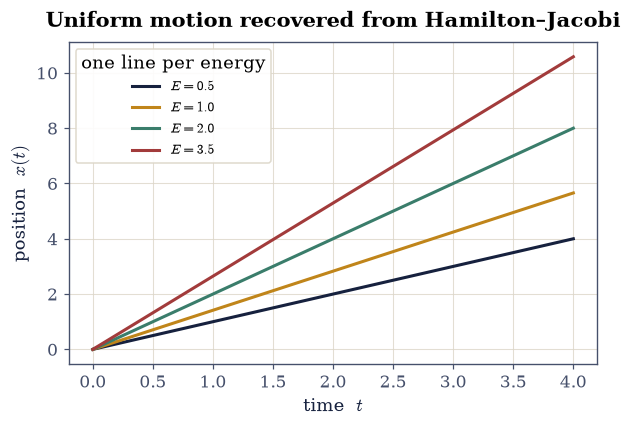

In [4]:
# (solution hidden on the public site)


### Validation 1 — the free-particle Hamilton–Jacobi solution

The residual of {eq}`eq-hj-idea` must vanish identically, and the recovered
velocity must equal $\sqrt{2E/m}$, i.e. $p/m$: the Hamilton–Jacobi solution
reproduces free uniform motion.

In [5]:
validate.check(
    hj_residual == 0,
    "S = √(2mE)x − Et satisfies the Hamilton–Jacobi equation (S_x)²/2m + S_t = 0",
)
validate.check(
    sp.simplify(velocity - sp.sqrt(2 * E_s / m_s)) == 0,
    "∂S/∂E = const gives uniform motion with velocity √(2E/m) = p/m",
)

✓  S = √(2mE)x − Et satisfies the Hamilton–Jacobi equation (S_x)²/2m + S_t = 0
✓  ∂S/∂E = const gives uniform motion with velocity √(2E/m) = p/m


True

## Exercise 2 — Hamilton's characteristic function and the momentum

The heart of {eq}`eq-hj-separation` is that the momentum is the *slope of the
action*: $\partial W/\partial q=p$. The test bed is the harmonic well
$V(q)=\tfrac12 m\omega^2q^2$ (with $m=\omega=1$) at a fixed energy $E$, whose
turning points sit at $q=\pm A$ with $A=\sqrt{2E/\omega^2}$. Because $W$ is an
integral, its slope has to be read with a central difference rather than by
differentiating the quadrature symbolically, and near the turning points the
square-root shape makes even that degrade — so the comparison is made at
interior points. The action and its slope are shown in
{numref}`fig-hj-characteristic`.

1. Write `momentum(q, E, V, m)`, the classical momentum
   $p(q)=\sqrt{2m[E-V(q)]}$ — the separated Hamilton–Jacobi equation
   {eq}`eq-hj-separation` solved for $\partial W/\partial q$ — clipped to zero
   outside the turning points so it stays real everywhere, and
   `characteristic_function(q, E, V, m, q0)`, Hamilton's characteristic
   function $W(q)=\int_{q_0}^{q}p\,\mathrm dq'$ of {eq}`eq-char-action` by
   `scipy.integrate.quad`. **Write these yourself** — the implementations are
   the lesson: an integrand that *is* the momentum, and an integral that *is*
   the action.
2. For the oscillator at energy $E$, compute $W(q)$ on a grid inside the
   turning points.
3. Confirm $\partial W/\partial q=p(q)$ at several interior points by a
   central difference of $W$, comparing against `momentum`.

In [6]:
# (solution hidden on the public site)


turning point A = 2.0
dW/dq : [1.6      1.907878 1.907878 1.6     ]
p(q)  : [1.6      1.907878 1.907878 1.6     ]
max |dW/dq − p| = 1.7603563051693527e-10


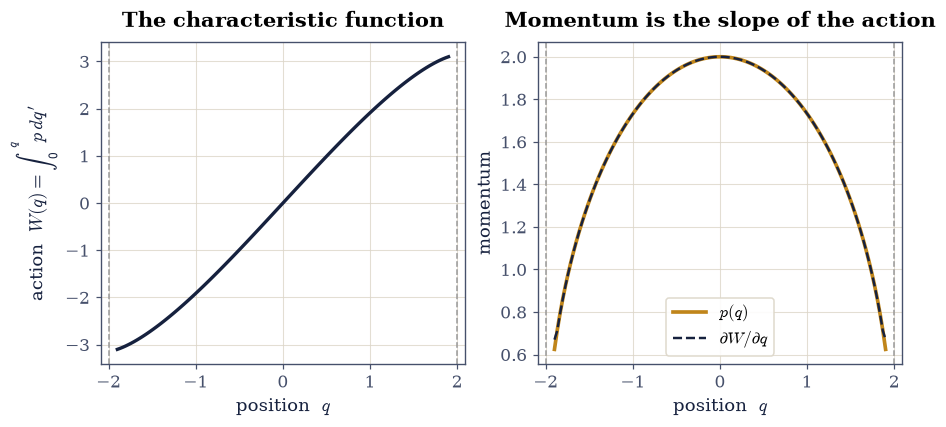

In [7]:
# (solution hidden on the public site)


### Validation 2 — the momentum is the slope of the action

At interior points (away from the turning points, where the square-root slope
diverges and a finite difference degrades) the central-difference slope of $W$
must match $p(q)$ to high accuracy: this is $\partial W/\partial q=p$, the
defining property {eq}`eq-char-action` of the characteristic function.

In [8]:
validate.close(
    dW,
    p_test,
    "∂W/∂q = p(q): the momentum is the slope of Hamilton's characteristic function",
    rtol=1e-5,
    atol=1e-6,
)

✓  ∂W/∂q = p(q): the momentum is the slope of Hamilton's characteristic function   [max|Δ| = 1.76036e-10 (rtol=1e-05, atol=1e-06)]


True

## Exercise 3 — The harmonic oscillator by Hamilton–Jacobi

Now the full machine on the oscillator. With $W(q)=\int p\,\mathrm dq$ in hand,
the trajectory comes from the same rule as before: the new coordinate $\partial
W/\partial E - t$ is a constant. Working the integral analytically,
$\partial W/\partial E=\int \frac{\partial p}{\partial E}\,\mathrm
dq=\frac1\omega\arcsin(q/A)$, so setting $\partial W/\partial E-t=\text{const}$
gives $\arcsin(q/A)=\omega t+\varphi$, i.e. $q(t)=A\sin(\omega t+\varphi)$ —
simple harmonic motion, straight from the Hamilton–Jacobi equation. The
independent yardstick is Hamilton's equations themselves, $\dot q=\partial
H/\partial p=p/m$ and $\dot p=-\partial H/\partial q=-m\omega^2q$, integrated
numerically from the state $(q_0,p_0)=(A\sin\varphi,\,m\omega A\cos\varphi)$
that matches the analytic solution at $t=0$ ({numref}`fig-hj-oscillator`).

1. Assemble the Hamilton–Jacobi solution $q(t)=A\sin(\omega t+\varphi)$
   with $A=\sqrt{2E/(m\omega^2)}$.
2. Write `hamilton_osc(t, y)`, Hamilton's equations above as a first-order
   system in $y=[q,\,p]$ (the time argument is unused — `solve_ivp` requires
   it). **Write this one yourself** — the implementation is the lesson: this
   two-line right-hand side *is* the dynamics that Hamilton–Jacobi theory
   claims to have solved in advance.
3. Integrate it with `scipy.integrate.solve_ivp` (`DOP853`) from that matching
   initial state, and confirm the two $q(t)$ agree.

In [9]:
# (solution hidden on the public site)


max |q_HJ − q_numeric| = 3.019806626980426e-11


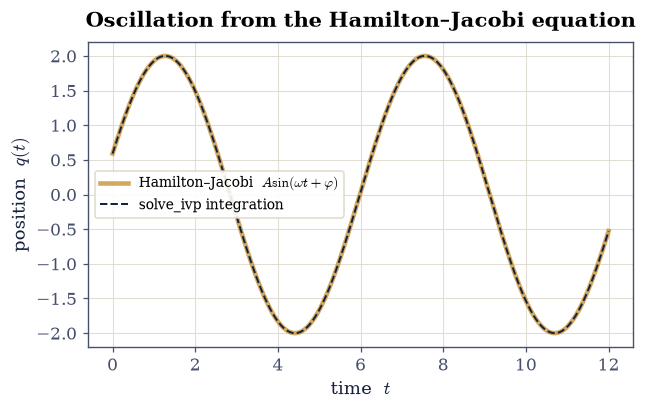

In [10]:
# (solution hidden on the public site)


### Validation 3 — Hamilton–Jacobi reproduces the oscillation

The analytic Hamilton–Jacobi trajectory and the numerically integrated one are
the same physics by two routes, so they must agree to integration tolerance.

In [11]:
validate.close(
    q_hj,
    q_num,
    "q(t) = A sin(ωt+φ) from Hamilton–Jacobi matches the integrated motion",
    rtol=1e-6,
    atol=1e-7,
)

✓  q(t) = A sin(ωt+φ) from Hamilton–Jacobi matches the integrated motion   [max|Δ| = 3.01981e-11 (rtol=1e-06, atol=1e-07)]


True

## Exercise 4 — Action-angle variables for the oscillator (the centerpiece)

Here is the payoff. For bounded motion the action $J=\frac1{2\pi}\oint
p\,\mathrm dq$ from {eq}`eq-action-angle` is the enclosed phase-space area over
$2\pi$, and it is a constant of the motion; its conjugate angle advances
linearly at the frequency $\omega=\partial H/\partial J$. For the oscillator the
orbit $p^2/2m+\tfrac12 m\omega^2q^2=E$ is an ellipse of area $2\pi E/\omega$, so
$J=E/\omega$ and $H(J)=\omega J$ — whence $\partial H/\partial J=\omega$.

Two facts make the action computable. For libration the loop runs out to a
turning point and back, so $\oint p\,\mathrm dq$ is twice the integral across
the well and $J=\frac1\pi\int_{q_1}^{q_2}p\,\mathrm dq$. And because $H(J)$ is
the inverse of $J(E)$, the frequency is $\partial H/\partial J=(\partial
J/\partial E)^{-1}$ — a derivative in $E$, which a central difference supplies.
The angle conjugate to $J$ is $\theta=\operatorname{atan2}(-p/m\omega,\,q)$, the
polar angle of the phase-space orbit, and it should advance at exactly that
$\omega$ ({numref}`fig-hj-action-angle`).

1. Write `action_variable(E, V, search, m)`, the action of
   {eq}`eq-action-angle` as $\frac1\pi\int_{q_1}^{q_2}p\,\mathrm dq$: turning
   points from the Setup's `classical_turning_points`, integrand the `momentum`
   you wrote in Exercise 2, quadrature by `scipy.integrate.quad`. **Write this
   one yourself** — the implementation is the lesson.
2. Compute $J$ for the oscillator at energy $E$ and confirm $J=E/\omega$.
3. Write `frequency_from_action(E, V, search, m, dE)`, the frequency
   $\omega=\partial H/\partial J=(\partial J/\partial E)^{-1}$, the energy
   derivative taken as a central difference of your `action_variable`. **Write
   this one yourself** — the implementation is the lesson.
4. Confirm the frequency it returns equals the oscillation frequency.
5. From an orbit integrated with your Exercise 3 `hamilton_osc`, form the angle
   $\theta=\operatorname{atan2}(-p/m\omega,\,q)$ (`numpy.arctan2` +
   `numpy.unwrap`) and confirm it advances linearly at rate $\omega$
   (`numpy.polyfit`).

In [12]:
# (solution hidden on the public site)


J = (1/2π)∮p dq = 2.000000    E/ω = 2.000000
∂H/∂J = 1.000000    ω = 1.000000


dθ/dt (linear fit) = 1.000000    ω = 1.000000


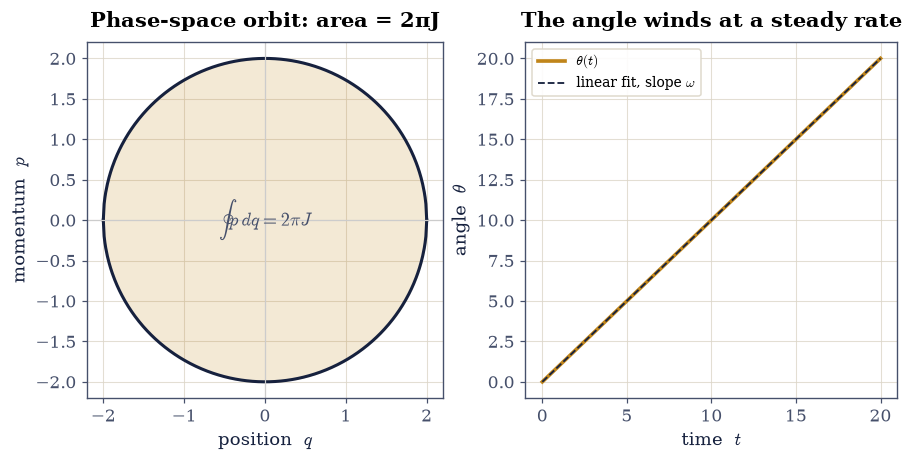

In [13]:
# (solution hidden on the public site)


### Validation 4 — the action is E/ω and its frequency is ω

Three facts must hold together: the quadrature action equals $E/\omega$; the
derivative $\partial H/\partial J$ equals the oscillation frequency $\omega$;
and the angle variable advances linearly at that same $\omega$. Together they
are the statement that action-angle variables trivialize the oscillator.

In [14]:
validate.close(
    J_quad,
    E2 / omega,
    "J = (1/2π)∮p dq equals E/ω for the oscillator",
    rtol=1e-5,
    atol=1e-6,
)
validate.close(
    omega_from_J,
    omega,
    "∂H/∂J recovers the oscillation frequency ω",
    rtol=1e-4,
    atol=1e-5,
)
validate.close(
    slope,
    omega,
    "the angle variable advances linearly at rate ω",
    rtol=1e-4,
    atol=1e-5,
)

✓  J = (1/2π)∮p dq equals E/ω for the oscillator   [got 2 vs expected 2 (rtol=1e-05, atol=1e-06)]
✓  ∂H/∂J recovers the oscillation frequency ω   [got 1 vs expected 1 (rtol=0.0001, atol=1e-05)]
✓  the angle variable advances linearly at rate ω   [got 1 vs expected 1 (rtol=0.0001, atol=1e-05)]


True

## Exercise 5 — Adiabatic invariance (student-implemented)

The action earns its importance from what it does under *change*. Take an
oscillator whose frequency $\omega(t)$ is drawn slowly upward — slowly meaning
over many periods — and ask what survives. The energy does not: pump the spring
stiffer and the oscillation gains energy. But the **action** $J=E/\omega$ is an
**adiabatic invariant**: it is nearly conserved, to a degree that improves the
more slowly the change is made. This is the classical root of the adiabatic
theorem, and of the old quantum theory's faith that quantized actions stay
quantized as atoms are perturbed. The ramp used here is linear, $\omega$ climbing
from $\omega_0=1$ to $\omega_1=2.5$ over a time $T=400$ — many oscillations per
unit of change, which is what *slow* has to mean. With the frequency now time-
dependent the energy is the instantaneous $E(t)=\tfrac12 p^2/m+\tfrac12
m\omega(t)^2q^2$, and the diagnostic is $J(t)=E(t)/\omega(t)$.

1. Write `omega_ramp(t)`, the linear ramp $\omega_0\to\omega_1$ over $T$, and
   `osc_ramped(t, y)`, the oscillator's equations of motion with that
   time-dependent frequency, $\dot q=p$ and $\dot p=-\omega(t)^2q$. **Write
   these yourself** — the implementations are the lesson.
2. Integrate over the whole ramp with `scipy.integrate.solve_ivp` (`DOP853`).
3. Form the instantaneous energy $E(t)$ and the action $J(t)=E(t)/\omega(t)$.
4. Show that $E$ changes by the ratio $\omega_1/\omega_0$ while $J$ stays
   nearly constant.

In [15]:
# (solution hidden on the public site)


E: 0.5000 → 1.2497   (ratio 2.499, expect ω1/ω0 = 2.500)
J: 0.5000 → 0.4999   (relative drift 3.71e-03)


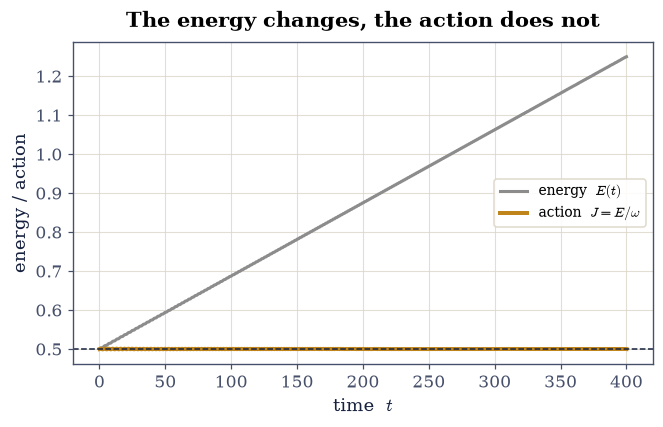

In [16]:
# (solution hidden on the public site)


### Validation 5 — the action survives the slow change

Adiabatic invariance is not exact — it holds in the limit of infinitely slow
change — so the honest check is that $J$ drifts by far less than $E$ does. With
this ramp $E$ moves by a factor of $2.5$ while $J$ holds to about a percent.

In [17]:
validate.conserved(
    J_t,
    "the action J = E/ω is an adiabatic invariant under the slow frequency ramp",
    rel_drift=2e-2,
)
validate.check(
    E_t[-1] / E_t[0] > 2.0,
    "meanwhile the energy E changes by the ramp ratio ω1/ω0 ≈ 2.5 (not conserved)",
)

✓  the action J = E/ω is an adiabatic invariant under the slow frequency ramp   [max relative drift = 0.00187367 (limit 0.02)]
✓  meanwhile the energy E changes by the ramp ratio ω1/ω0 ≈ 2.5 (not conserved)


True

## Exercise 6 — Toward quantization: the action and Bohr–Sommerfeld (student-implemented)

The old quantum theory of Bohr and Sommerfeld made one bold postulate: that the
action variable is **quantized**, $\oint p\,\mathrm dq=n h$ with $n=1,2,\dots$
For the oscillator $\oint p\,\mathrm dq=2\pi E/\omega$, so the rule gives
$E_n=n\hbar\omega$ — the correct *ladder spacing* $\hbar\omega$, but resting on
the floor instead of half a rung above it. The missing $\tfrac12$ is the
zero-point energy, and it is exactly what Volume VI's WKB approximation ([§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb))
restores by tracking the phase the wave picks up at the turning points,
sharpening the rule to $\oint p\,\mathrm dq=(n+\tfrac12)h$. The two ladders are
drawn against each other in {numref}`fig-hj-quantization`.

1. For the oscillator, evaluate $\oint p\,\mathrm dq=2\pi J$ with the
   `action_variable` you wrote in Exercise 4, at a trial energy, and confirm it
   equals $2\pi E/\omega$.
2. Impose $\oint p\,\mathrm dq=n h$ (with $\hbar=1$, $h=2\pi$) and solve
   for $E_n$; confirm $E_n=n\hbar\omega$.
3. Note the old-quantum ladder $n\hbar\omega$ against the true
   $(n+\tfrac12)\hbar\omega$ — the correction WKB will supply.

In [18]:
# (solution hidden on the public site)


∮p dq = 12.566371    2πE/ω = 12.566371
Bohr–Sommerfeld  E_n = n ħω : [1. 2. 3. 4. 5.]
true (n+½)ħω               : [1.5 2.5 3.5 4.5 5.5]


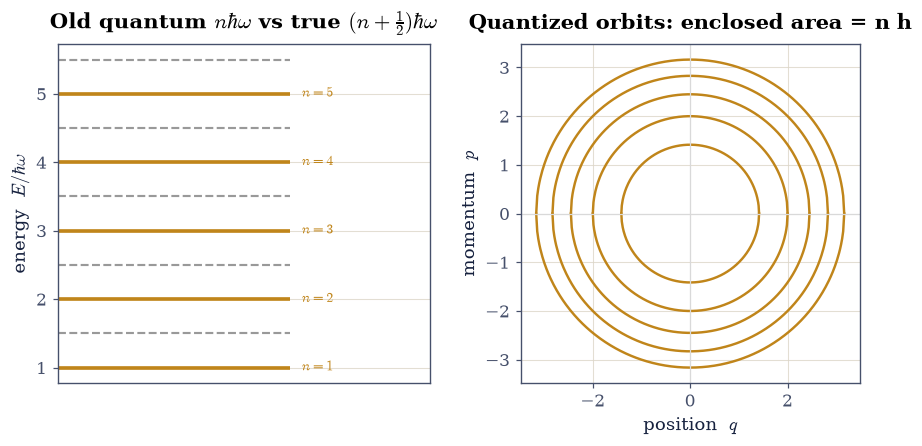

In [19]:
# (solution hidden on the public site)


### Validation 6 — the old quantization gives Eₙ = nℏω

The action quantized as $\oint p\,\mathrm dq=n h$ must return the oscillator
ladder $E_n=n\hbar\omega$: the right spacing $\hbar\omega$, short by the
zero-point $\tfrac12\hbar\omega$ that WKB ([§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb)) will add.

In [20]:
validate.close(
    loop,
    2 * np.pi * E2 / omega,
    "∮p dq = 2πE/ω for the oscillator",
    rtol=1e-5,
    atol=1e-6,
)
validate.close(
    E_old,
    n_levels * hbar * omega,
    "Bohr–Sommerfeld ∮p dq = nh gives E_n = nℏω (old quantum theory)",
    rtol=1e-6,
    atol=1e-9,
)

✓  ∮p dq = 2πE/ω for the oscillator   [got 12.5664 vs expected 12.5664 (rtol=1e-05, atol=1e-06)]
✓  Bohr–Sommerfeld ∮p dq = nh gives E_n = nℏω (old quantum theory)   [max|Δ| = 0 (rtol=1e-06, atol=1e-09)]


True

## Exercise 7 — (Synthesis) The action as the shadow of a wave

Hamilton–Jacobi theory set out to find a change of variables that would freeze
the motion into constants, and found it in the classical **action** — a single
function $S$ whose gradient is the momentum, whose level sets $S=\text{const}$
are wavefronts, and whose invariant tori the action variables label. Along the
way the action revealed itself as the robust survivor of slow change (the
adiabatic invariant of Exercise 5) and as the quantity the old quantum theory
quantized (Exercise 6). But its deepest property is the one in its units. The
action carries the dimensions of $\hbar$, which is to say the dimensions of a
**phase**, and the equation it obeys is precisely what the Schrödinger equation
becomes when the wavelength shrinks to nothing, {eq}`eq-action-phase`.

{numref}`fig-hj-eikonal` draws the picture that Volume VI makes literal. Surfaces
of constant action are **wavefronts**; the momentum $p=\nabla S$ points along the
**rays** that cross them at right angles — the classical trajectories. A particle
following Hamilton's equations is a ray of a wave whose phase is $S/\hbar$, and
geometrical optics is to wave optics exactly as classical mechanics is to quantum
mechanics. Hamilton wrote his equation in the 1830s, decades before anyone
suspected the electron was a wave, yet he built mechanics in the language of
phases and wavefronts — as if the theory knew, before we did, what it would one
day become. Volume VI picks up exactly here: it lets $\hbar$ be small but
nonzero, and the action we computed in this notebook becomes the phase of a real
matter wave. That is the WKB approximation ([§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb)), and the Bohr–Sommerfeld rule
of Exercise 6 returns with its missing $\tfrac12$ restored.

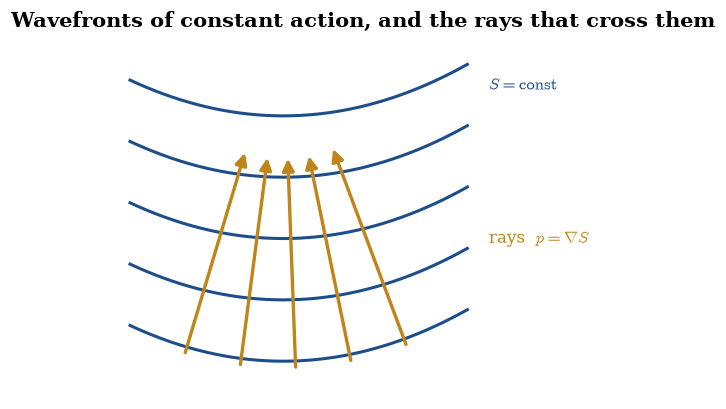

In [21]:
# (solution hidden on the public site)


## Notebook summary

- **The Hamilton–Jacobi equation** {eq}`eq-hj-idea` seeks a canonical
  transformation to constants; its generator is the action $S=W-Et$
  {eq}`eq-hj-separation`, with the momentum as its slope, $\partial W/\partial
  q=p$. We recovered free uniform motion and the full oscillation from it.
- **Action-angle variables** {eq}`eq-action-angle`: the action
  $J=\frac1{2\pi}\oint p\,\mathrm dq=E/\omega$ is constant and the angle winds at
  $\omega=\partial H/\partial J$ (verified three ways for the oscillator).
- **Adiabatic invariance**: under a slow frequency ramp the energy changed by
  $2.5\times$ while the action held to about a percent — the robust invariant.
- **The old quantization** $\oint p\,\mathrm dq=nh$ gave $E_n=n\hbar\omega$, the
  right spacing missing its zero-point $\tfrac12\hbar\omega$.
- **The action is a phase**: $S=\text{const}$ are wavefronts, $p=\nabla S$ the
  rays, and the Hamilton–Jacobi equation is the $\hbar\to0$ limit of Schrödinger
  {eq}`eq-action-phase` — the bridge to Volume VI.

## Outlook

- **The WKB / semiclassical approximation** (Volume VI, [§6.23](../06-quantum-mechanics/wkb-semiclassical.ipynb)): $\psi\sim
  e^{iS/\hbar}$ with $S$ the very action computed here, and Bohr–Sommerfeld
  sharpened to $(n+\tfrac12)h$ by the turning-point phases.
- **Wave mechanics** (Volume VI): the Schrödinger equation whose short-wavelength
  limit is the Hamilton–Jacobi equation, and the position-space wavefunction
  ([§6.9](../06-quantum-mechanics/position-representation.ipynb)) whose phase is the action.
- **Integrable systems and chaos** ([§5.5](../05-classical-stat-mech/ergodicity.ipynb)): action variables label the
  invariant tori; when no separation exists the tori break and the motion turns
  ergodic — KAM theory as a horizon.
- **Canonical perturbation theory**: expanding the action of a nearly-integrable
  system in the small perturbation, with action variables as the unperturbed
  coordinates.

### References

```{bibliography}
:filter: docname in docnames
```

In [22]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>